# Introduction to MCMC

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/master/iddinf/intro_to_mcmc.ipynb)

## LEARNING OUTCOMES
- Understand the components of a MCMC (Markov chain Monte Carlo) algorithm and some common MCMC algorithms
- Use the MCMC toolset that `gemlib` provides to run the Metropolis-Hastings algorithm on simulated data from a SIR model to estimate the parameters

## Introduction

In this notebook, we simulate data from a homogeneously mixing stochastic SIR model, and then use the inference tools in `gemlib` to estimate the transmission rate and recovery rate parameters.

## MCMC theory

### What is MCMC?

- Class of algorithms used to draw samples from a probability distribution, known as the target or posterior distribution – which we specify with the likelihood and prior distribution(s)
- Goal is to perform probabilistic inference to find parameter values (and sometimes missing data)
- MCMC methods are used to infer probability distributions that are too high dimensional or complex to be estimated solely with analytical methods
- Algorithms produce Markov chains and are constructed in such a way that the stationary distribution of these Markov chains is equal to the posterior distribution. This means that provided the algorithms are run long enough, they will draw samples from the posterior distribution.
- Advantage: Overcome the inefficiency of rejection sampling in high dimensions (due to the _curse of dimensionality_ – exponential increase in probability of rejection as number of dimensions increases) by staying in regions of high probability if already there
- Disadvantage: Do so at the expense of independent samples (samples are autocorrelated, so need more samples to get as good an estimate of the posterior distribution)

### Components of a MCMC algorithm:
There are three main components of a MCMC algorithm:
- proposal distribution
- acceptance probability calculation
- accept/reject step

### Common algorithms



#### Metropolis-Hastings
- The canonical MCMC algorithm
- Consists of repeating the following steps many times:
  1. Propose a new value of the parameter based on the current value.
  2. Calculate the ratio of the posterior probability of the data given this value to that given the current value multiplied by the ratio of the proposal probabilities (the probability of proposing the old value given the new value divided by the probability of proposing the new value given the old value). This is the acceptance probability.
  3. Accept/reject the proposed value with probability equal to the acceptance probability.

**Metropolis-Hastings (MH) algorithm:**
1. Start from some initial value $\theta^{(0)}$ (e.g. drawn from the prior distribution $\pi_0(\theta)$)
2. Propose a new value $\theta'$ from the proposal distribution $q(\theta'|\theta^{(i)})$
3. Calculate the acceptance probability:

\begin{equation*}
\alpha=\min\left(1,\frac{\pi(\theta'|y)}{\pi(\theta^{(i)}|y)}\frac{q(\theta^{(i)}|\theta')}{q(\theta'|\theta^{(i)})}\right)
\end{equation*}

where $\pi(\theta|y)\propto L(\theta;y)\pi_0(\theta)$ is the posterior distribution, and $L(\theta;y)=f(y|\theta)$ is the likelihood of observing the data $y$ given the parameters $\theta$
4. Set $\theta^{(i+1)}=\theta$ with probability $\alpha$, otherwise set $\theta^{(i+1)}=\theta^{(i)}$
5. Repeat the above steps $K$ times

- Need to write down the likelihood of the model (see earlier sessions).
- Have to pick prior distributions for parameters, which should reflect your prior beliefs/knowledge about their values. Many possibilities.
- Proposal distribution can be symmetric (e.g., Normal distribution) or asymmetric. When it's symmetric, algorithm is known as random walk Metropolis (RWM).
- In multiple dimensions, you can update one parameter at a time (single-site or single-component updates) or update multiple parameters together (multi-site or block updates), e.g., with a multivariate Normal proposal distribution with a suitably chosen covariance matrix.
- Need to tune the variance of the proposal distribution, which determines how big the jump between the current value and the proposed value is, to ensure that the chain *mixes* well.
- Need to run the chain long enough that it has *converged* and samples are being drawn from the posterior distribution.
- Issues:
  - Samples are autocorrelated, and the effective sample size (ESS) (equivalent number of independent samples) may be much lower than the number of samples taken.
  - The Markov chain eventually converges to the correct distribution, but it may take a long time to do so, and initial samples typically follow a different distribution, especially if the chain is started in a low-probability region. So a *burn-in* period is needed, and the samples from this period need to be discarded.
  - Tends to also suffer from the curse of dimensionality as the number of dimensions increases.
- These issues can, to some extent, be tackled by running the chain for longer, thinning (only taking every Xth sample), and using techniques like adaptive tuning of the proposal (co)variance.

#### Gibbs sampler
- An algorithm for sampling from a multidimensional probability distribution, $\pi(\theta|y)$ where $\theta=(\theta_1,\dots,\theta_n)$, when sampling from the joint distribution is difficult but sampling from the conditional distributions, $\pi(\theta_j|\theta_{-j},y)$ where $\theta_{-j}=(\theta_1,\dots,\theta_{j-1},\theta_{j+1},\dots,\theta_n)$, is more straightforward.
- The sequence of samples drawn from the conditional distributions can be used to approximate the joint posterior distribution, or marginal distributions, or expected value of some function of the parameters/missing data.
- Consists of drawing a sequence of samples by sampling in turn from each of the conditional distributions of the parameters given the current values of the other parameters.
- It is a special case of the Metropolis-Hastings algorithm in which the proposal is always accepted.

- **Gibbs sampler algorithm:**
  1. Start with some initial value of the parameter vector $\theta^{(0)}=(\theta_1^{(0)},\dots,\theta_j^{(0)},\dots,\theta_n^{(0)})$
  2. Draw $\theta_j^{(i+1)}\sim\pi(\theta_j^{(i+1)}|\theta_1^{(i+1)},\dots,\theta_{j-1}^{i+1},\theta_{j+1}^{(i)},\dots,\theta_n^{(i)},y)$
  3. Repeat the above steps $K$ times

#### Hamiltonian Monte Carlo (HMC)
- HMC is a gradient-based MCMC algorithm that uses the gradient of the log posterior and Hamiltonian dynamics to propose new points in the parameter space.
- It helps to overcome some of the issues of the M-H algorithm such as:
  - the difficulty of tuning the proposal variance in high dimensions
  - slow convergence in high dimensions
  - inefficient exploration of the parameter space, particularly in high dimensions
- It is implemented in Stan and TensorFlow but we will not cover its use in this course.

#### Metropolis-within-Gibbs (MwG)
- The MwG algorithm is essentially a generalisation of the Gibbs sampler that allows parameter updates made with Gibbs steps to be replaced by Metropolis-Hastings steps.
- It is used in the scenario in which it is no longer straightforward to sample some parameters directly from their conditional posterior distributions, but it is possible to update them with a M-H step.
-  It is particularly useful in the context of data augmentation MCMC (DA-MCMC), where it may be possible to draw the parameters from their conditional posterior distribution $\pi(\theta|X,y)$ using a Gibbs step, but it is not straightforward to draw the missing data $X$ from its conditional distribution $\pi(X|\theta,y)$ as this is typically not available in closed form.


```{exercise}
:label: ex8.1

Here's a nice [visualisation](https://chi-feng.github.io/mcmc-demo/app.html) of some of these algorithms. Have a play with the different algorithm options and target distributions to see the behaviour and performance of the different algorithms. (You may wish to set the autoplay delay to a smaller value and click "Reset".)
```

## Building an example model

Let's first develop an example model, which we can then fit to some data.

### Install `gemlib`

We'll start by installing the `gemlib` library.

In [1]:
from warnings import warn

try:
    import google.colab
    !pip install -Uq gemlib
except:
    warn("Not running in Colab, make sure `gemlib` is installed locally")

/tmp/ipykernel_3289806/1793800732.py:7: UserWarning: Not running in Colab, make sure `gemlib` is installed locally
  warn("Not running in Colab, make sure `gemlib` is installed locally")


and now import the modules we need for this notebook...

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple

import tensorflow_probability.substrates.jax as tfp

import gemlib
from gemlib.distributions import DiscreteTimeStateTransitionModel

tfd = tfp.distributions

import seaborn as sns

%matplotlib inline

DTYPE=np.float32

sns_c = sns.color_palette(palette = "Dark2")

### The epidemic model

We're going to model our epidemic using a SIR model, where individuals begin as susceptible, become infected, and recover from their infection.

Here, we have 3 _states_: $S$, $I$, and $R$ representing susceptible, infected, and recovered individuals respectively.

We then have two transitions, $S \rightarrow I$ and $I \rightarrow R$, for which we assume transition rates

\begin{align*}
\lambda^{SI} &= \beta I/N + \epsilon \\
\lambda^{IR} &= \gamma
\end{align*}


### Incidence matrix

In [3]:
incidence_matrix = np.array(
    [ #  SI  IR
        [-1,  0],  # S
        [ 1, -1],  # I
        [ 0,  1],  # R
    ],
    dtype=DTYPE
)

### Initial state

In [4]:
popsize = 1000

initial_state = np.array([[999, 1, 0],
                          ]).astype(DTYPE)

### The discrete-time model

Armed with the data structures and functions above, we can now instantiate the `DiscreteTimeStateTransitionModel`

In [5]:
def sir_model(beta, gamma):
    
    def si_rate(t, state):
        return beta * state[:, 1] / state.sum(axis=-1)
    
    def ir_rate(t, state):
        return gamma
    
    return DiscreteTimeStateTransitionModel(transition_rate_fn=[si_rate, ir_rate],
                                            incidence_matrix=incidence_matrix,
                                            initial_state=initial_state,
                                            initial_step=0,
                                            time_delta=1.0,
                                            num_steps=100,
                                            name="sir")

```{exercise}
:label: ex8.2

Run a simulation using the `sample` method for the `DiscreteTimeStateTransitionModel`.

- Check the shape of the output. What are its dimensions?
- Run a simulation using the `sample` method, but with the seed set to `jax.random.key(1)`
- Plot the number of SI and IR transitions over time
```

````{solution-start} ex8.2
:class: dropdown
````

In [6]:
sir = sir_model(beta=0.3, gamma=0.1)
sir_sim = sir.sample(seed=jax.random.key(1))
sir_sim.shape

(100, 1, 2)

`sample()` spits out a transition events tensor of dimension [T, N, L] for  $T$  timesteps, $N$  metapopulations or individuals (in this case $N = 1$),  and  $L$  transitions. In the case of a metapopulation model, this is a tensor $Z=(z^{qr}_{ti})$, where $z^{qr}_{ti}$ records the number of transitions from state $q$ to state $r$ in metapopulation $i$ at timestep $t$. For an individual-level model, $z^{qr}_{ti}=1$ if individual  $i$ undergoes a transition from state $q$ to state $r$ at timestep $t$ and $z^{qr}_{ti}=0$ otherwise.

We can therefore compute the total number of each type of transition happening on each day by taking the sum across the second dimension (i.e. $N$) of the tensor. In the context of our SIR model this is, of course, equivalent to plotting the daily absolute incidence of infection and recovery events.

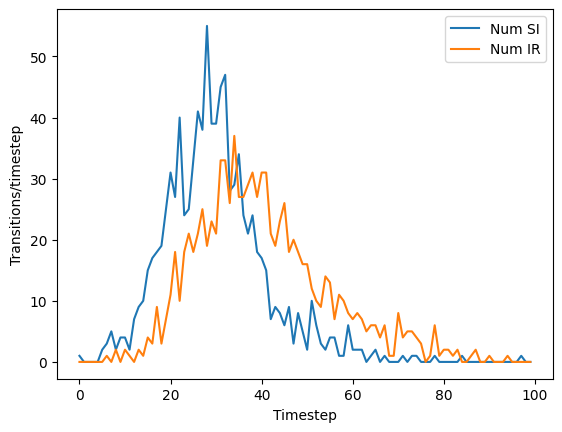

In [7]:
plt.plot(sir_sim[:, 0, :], label=["Num SI", "Num IR"])
plt.xlabel("Timestep")
plt.ylabel("Transitions/timestep")
plt.legend()

To get the number of individuals in each state over time, we can use the `compute_state` method of the `sir` model on our `sir_sim` object

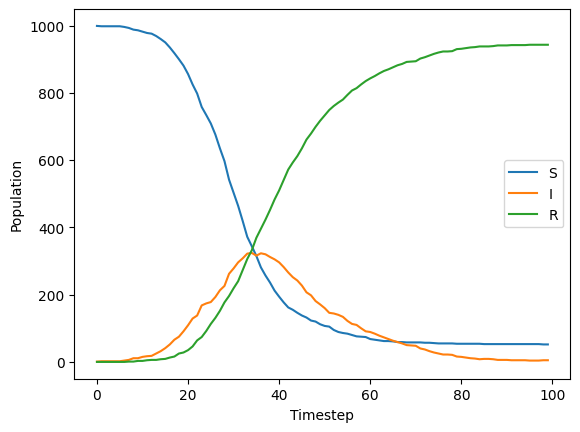

In [8]:
sir_sim_state = sir.compute_state(sir_sim)
plt.plot(sir_sim_state[:, 0, :], label=["S", "I", "R"])
plt.xlabel("Timestep")
plt.ylabel("Population")
_ = plt.legend()

````{solution-end}
````

### Using `jax.jit` for performance

You may have noticed that the simulation we have run above is not exactly snappy!  Since we're using JAX, we can use the power of just-in-time compilation to accerate it.  All we need to do is wrap the call to `sir.sample()` in the `jax.jit` decorator, i.e. write a function that returns the `sir.sample()` function with a given random seed and put `@jax.jit` above the function definition.

```{exercise}
:label: ex8.3

Have a go at using JIT compilation and time how long it takes to run a simulation of the SIR model versus the non-JIT-compiled function. Which is faster?
```

````{solution-start} ex8.3
````

First we time the non-JIT compiled function:

In [9]:
%time sir_sim_graph = sir.sample(seed=jax.random.key(5))

CPU times: user 6.46 s, sys: 87.4 ms, total: 6.54 s
Wall time: 1.32 s


Okay, that's our benchmark.  Now let's try JIT-compilation:

In [10]:
@jax.jit
def compiled_sample(seed):
    return sir.sample(seed=seed)

%time sample = compiled_sample(seed=jax.random.key(5))

CPU times: user 7.2 s, sys: 135 ms, total: 7.33 s
Wall time: 1.54 s


Erm...that's slower! Let's run it again...

In [11]:
%time sample = compiled_sample(seed=jax.random.key(5))

CPU times: user 1.83 ms, sys: 975 μs, total: 2.81 ms
Wall time: 641 μs


That's lots quicker!  When we first ran our JIT-compiled function, it took time for the compiler to build the machine code required to implement the function.  When we ran it for a second time, the compilation had already been done so all that's left is the runtime.  Try running this notebook again using a GPU runtime, and see if you get any difference in speed...

````{solution-end}
````

<a name="log-lik-simple"></a>
### Log-likelihood computation

The last thing in this section that we'll look at is how to compute the probability of obtaining a given timeseries of transition events given the parameters, initial state, and indeed the model.  This is, of course, cruicial for inference, as we describe in the next section.

This is super-easy to compute, just using `DiscreteTimeStateTransitionModel`'s `log_prob` method.

In [12]:
sir.log_prob(sir_sim)

Array(-368.84668, dtype=float32)

## Bayesian Inference

Now we have a working model (and simulated data), we can use it to construct a Bayesian model by specifying prior distributions for it.

Let our epidemic model be written as

$$
Z \sim \mbox{SIR}(\beta, \gamma, \mathbf{x}_0)
$$

where $Z$ is the output transition events tensor (`sir_sim` above), $\mathbf{x}_0$ is the initial state, and $\theta = \{\beta, \gamma\}$ are the parameters.  We place priors on the parameters such that

\begin{align*}
\beta & \sim \mbox{Gamma}(1.0, 5.0) \\
\gamma & \sim \mbox{Gamma}(1.0, 0.5)
\end{align*}


### Implementing a Bayesian model

To build this model, we essentially have to specify a probabilistic DAG.  In code, we do this by using the TensorFlow Probability `JointDistributionCoroutineAutoBatched` class.  

Notice that I've specified the entire model from scratch.  This is required because if we change the value of a parameter (as an optimiser or MCMC algorithm will), then we need to re-instantiate the model with the new parameter value.

* Think about this in terms of the Bayesian DAG, and how we write probability distributions as above, to see why this is sensible.
* It's also computing best practice -- wrapping all the logic into functions guards against unexpected results due to global variables being changed when you're not looking!

In [13]:
@tfd.JointDistributionCoroutineAutoBatched
def model():
    # Priors
    beta = yield tfd.Gamma(
            concentration=DTYPE(1.0), rate=DTYPE(5.0), name="beta"
    )
    
    gamma = yield tfd.Gamma(
            concentration=DTYPE(1.0), rate=DTYPE(0.5), name="gamma"
    )

    yield sir_model(beta, gamma)

### Prior simulation

So we now have an instantiated model, but what can we do with it? The first thing we might like to do is to simulate from the _prior_ model.  That is, draw the parameters from their respective prior distributions, plugging the resulting values into the SIR model and then simulating from it.  In other words, we start at the top of the DAG, and work our way downwards.

Given we've set up a `JointDistributionCoroutine`, this is very simple!  We just call the `sample()` method with a seed, and obtain a `StructTuple` of values for each of the distributions in our model.  TFP automatically takes care of drawing from the distributions in the correct order.

In [14]:
prior_sim = model.sample(beta = 0.2, seed=jax.random.key(42))


Of course, simulating from the prior distributions is not guaranteed to give us any sensible epidemic simulation output, as there is nothing constraining the parameters to be consistent with the data other than our _a priori_ belief about their values.  Even if we specified carefully chosen marginal prior distributions for the parameters, there is nothing stopping us simulating combinations of parameters that lead to non-sensical epidemic output.  

What we need to do is _condition_ the model on having observed some epidemic output, and then find a way to work out the joint _a posteriori_ distribution of the parameters in the light of these observations.  

Bayes' Theorem tells us that

$$
Pr(\theta | Z, \mathbf{x_0}) = \frac{Pr(Z | \theta, \mathbf{x}_0)Pr(\theta)}{\int_{\Theta} Pr(Z | \theta, \mathbf{x_0})Pr(\theta) \mathrm{d}\theta}
$$

where $Pr(\theta | Z, \mathbf{x}_0)$ is the _posterior distribution_, $Pr(Z | \theta, \mathbf{x}_0)$ is the probability of observing the transition event timeseries $Z$ given the parameters and initial state $\mathbf{x}_0$, i.e. the likelihood, $Pr(\theta)$ is the (joint) prior distribution of the parameters.

In computing, conditioning a model is essentially the same as fixing the value of a given function argument, which TFP allows us to do with the `experimental_pin` method.

```{exercise}
:label: ex8.4

Condition the model on the simulated epidemic `sir_sim` from above and use the conditioned model to calculate the log-probability of the simulated data for $\beta=0.2$ and $\gamma=0.02$.
```

````{solution-start} ex8.4
:class: dropdown
````

In [15]:
conditioned_model = model.experimental_pin(sir=sir_sim)

In [16]:
conditioned_model.log_prob(beta=0.2, gamma=0.02)

Array(-1189.2554, dtype=float32)

````{solution-end}
````

The fact that we know this distribution only up to a constant is the reason we employ methods such as MCMC to draw samples from, and hence estimate, posterior distributions in all but the simplest of cases.  Readers are referred to the following texts for an in-depth discussion of these foundational principles:

* Gilks, W., Richardson, S., Spiegelhalter, D. (1995). Markov Chain Monte Carlo in Practice. Taylor & Francis. ISBN: 9780412055515
* Gelman, A., Carlin, J.B., Stern, H.S., Dunson, D.B., Vehtari, A., & Rubin, D.B. (2013). Bayesian Data Analysis (3rd ed.). Chapman and Hall/CRC. https://doi.org/10.1201/b16018

### Estimating parameters using MCMC

In this section, we'll use `gemlib.mcmc` to build a MCMC sampler to sample from the _joint posterior distribution_ of the parameters, assuming that the transition event timeseries is fully known.  MCMC is really a suite of algorithms designed to draw samples from un-normalised probability distributions.  Here, we will use the most basic of these algorithms, the Metropolis-Hastings algorithm.

In `gemlib`, we will use the functions `rwmh` (the Metropolis-Hastings _kernel_) and `mcmc` (the MCMC _driver_).  The first step is to instantiate the the Metropolis-Hastings algorithm

In [17]:
# construct RWM kernel
from gemlib.mcmc import mcmc, rwmh

kernel = rwmh(scale=0.01)

We now use the `mcmc` driver function to run the MCMC

In [18]:
samples, info = mcmc(
    num_samples = 10000,
    sampling_algorithm=kernel,
    target_density_fn=conditioned_model.log_prob,
    initial_position = conditioned_model.sample_unpinned(seed=jax.random.key(42)),
    seed = jax.random.key(1),
)

In [19]:
def trace_plot(samples):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # if not isinstance(samples, list):
    #     samples = [samples]
    if np.ndim(samples.beta)==1:
        # beta
        ax[0].plot(samples.beta, linewidth=1)
        # gamma
        ax[1].plot(samples.gamma, linewidth=1)
    else:
        # trace plots for parameters
        for i in range(num_chains):
            # beta
            ax[0].plot(samples.beta[:,i], color=sns_c[i], linewidth=1, alpha=0.3, label = 'Chain '+str(i))
            # gamma
            ax[1].plot(samples.gamma[:,i], color=sns_c[i], linewidth=1, alpha=0.3, label = 'Chain '+str(i))
        # legend
        handles, labels = ax[1].get_legend_handles_labels()
        fig.legend(handles, labels, loc=5, bbox_to_anchor=(1.2, 0.5), title="Chain")

    # subtitles
    ax[0].set_title('Trace plot of beta')
    ax[1].set_title('Trace plot of gamma')

    # axis limits
    # ax[0].set_ylim(0., 0.4)
    ax[1].set_ylim(0., 0.2)

    # true value lines
    ax[0].hlines(xmin=0, xmax=samples.beta.shape[0], y=0.3, color="red")
    ax[1].hlines(xmin=0, xmax=samples.beta.shape[0], y=0.1, color="red")

    # plot level axis labels
    ax[0].set_xlabel("Iteration")
    ax[1].set_xlabel('Iteration')
    fig.text(0.04, 0.5, 'Parameter Value', va='center', rotation='vertical')

    plt.show()

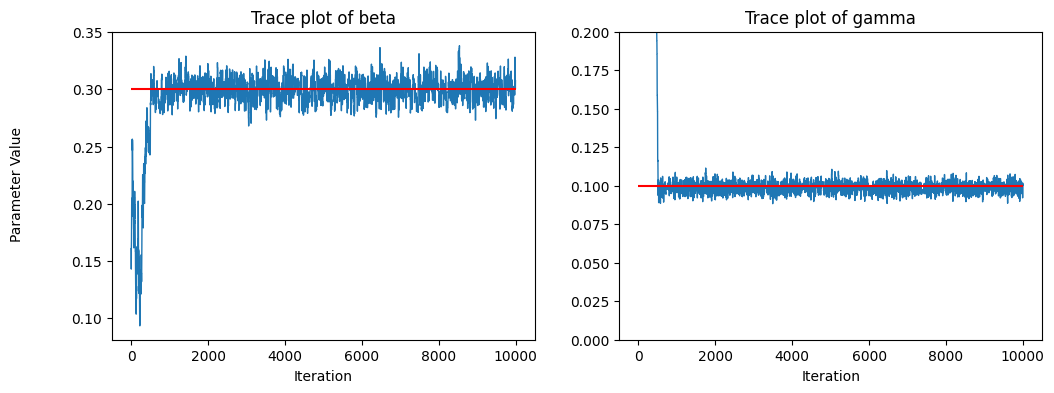

In [20]:
trace_plot(samples)